In [1]:
!pip install git+https://github.com/BirkhoffG/causalgraphicalmodels.git

  Cloning https://github.com/BirkhoffG/causalgraphicalmodels.git to /tmp/pip-req-build-zglq5naj
  Running command git clone --filter=blob:none --quiet https://github.com/BirkhoffG/causalgraphicalmodels.git /tmp/pip-req-build-zglq5naj
  Resolved https://github.com/BirkhoffG/causalgraphicalmodels.git to commit cd178afc246160d1d0ec996a4ec0652cba580205
  Preparing metadata (setup.py) ... done
  Created wheel for causalgraphicalmodels: filename=causalgraphicalmodels-0.0.5-py3-none-any.whl size=10533 sha256=d74d02f95dbae6fc1d39f17f6fe889ac573898521a1069ffe4e4af44f10ecf52
  Stored in directory: /tmp/pip-ephem-wheel-cache-r7a5a5rs/wheels/1b/0e/ba/784b5d2148fa37bbd66a77e4fc73ef30f2e422ee96bdad6a47
Successfully built causalgraphicalmodels


In [2]:
%pylab inline
%config InlineBackend.figure_format = 'retina'
from ipywidgets import interact
import scipy.stats as stats
import pandas as pd
import pymc as pm
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.gridspec as gridspec

import arviz as az ## This is new, but it is installed along with PyMC

## This is new for working with DAGs, you will have to install it
## uncomment the next box and run it
import causalgraphicalmodels as cgm
from causalgraphicalmodels import CausalGraphicalModel
import graphviz

from scipy.special import expit
import matplotlib.ticker as mtick

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

def credible_interval_from_samples(samples, prob):
    """`samples` can be an nd array. Assume that all of the dimensions
    except for the last index parameters while the last (rightmost)
    dimension indexes the samples."""
    samples_sorted = sort(samples, axis=-1)
    N_samples = samples.shape[-1]
    index = int(N_samples*(1 - prob)/2)
    lower = samples_sorted[..., index]
    upper = samples_sorted[..., -index]
    ## quantile(x, [(1 - prob)/2, (1 + prob)/2], axis=-1)
    return lower, upper

Populating the interactive namespace from numpy and matplotlib


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/509 project/Diabetes_Mexico_analysis.csv")

required = ["high_risk", "age", "sex", "sleep_cat","vig_days", "mod_days", "walk_days", "sedentary_min"]
model_df = df[required].copy()
for c in required:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")
model_df = model_df.dropna().copy()

# recoding
model_df["female"] = (model_df["sex"] == 2).astype(int)
model_df["age_c"] = model_df["age"] - model_df["age"].mean()
model_df["sedentary_hours"] = model_df["sedentary_min"] / 60
model_df["sedentary_hours_c"] = model_df["sedentary_hours"] - model_df["sedentary_hours"].mean()

## vig_days: 71.2% zeros -> binary (any vigorous activity vs none)
model_df["vig_active"] = (model_df["vig_days"] > 0).astype(int)

## sleep dummies, reference = 7h
sleep_label_map = {1: "<=5h", 2: "6h", 3: "7h", 4: "8h", 5: ">=9h"}
sleep_order = ["<=5h", "6h", "7h", "8h", ">=9h"]
model_df["sleep_label"] = model_df["sleep_cat"].map(sleep_label_map)
sleep_dummies = pd.get_dummies(model_df["sleep_label"], prefix="sleep", drop_first=False)
sleep_dummies = sleep_dummies.drop(columns=["sleep_7h"]).astype(int)

print(f"Sample size : {len(model_df)}")
print(f"High risk : {model_df['high_risk'].sum()} ({model_df['high_risk'].mean():.1%})")
print(f"Low risk : {(model_df['high_risk']==0).sum()}")
model_df.head()

Sample size : 1501
High risk : 469 (31.2%)
Low risk : 1032


,high_risk,age,sex,sleep_cat,vig_days,mod_days,walk_days,sedentary_min,female,age_c,sedentary_hours,sedentary_hours_c,vig_active,sleep_label
0,1,57.0,2,3.0,0.0,5.0,4.0,240.0,1,12.641572,4.0,-0.330202,0,7h
1,1,20.0,2,2.0,0.0,7.0,7.0,240.0,1,-24.358428,4.0,-0.330202,0,6h
2,1,38.0,1,3.0,0.0,0.0,0.0,540.0,0,-6.358428,9.0,4.669798,0,7h
3,1,63.0,2,5.0,0.0,0.0,0.0,480.0,1,18.641572,8.0,3.669798,0,>=9h
4,0,53.0,1,3.0,0.0,0.0,6.0,180.0,0,8.641572,3.0,-1.330202,0,7h


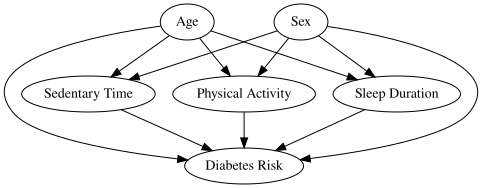

In [5]:
CausalGraphicalModel(
    nodes=['Age', 'Sex', 'Sedentary Time', 'Physical Activity', 'Sleep Duration', 'Diabetes Risk'],
    edges=[('Age', 'Sedentary Time'), ('Age', 'Physical Activity'), ('Age', 'Sleep Duration'), ('Age', 'Diabetes Risk'),
        ('Sex', 'Sedentary Time'), ('Sex', 'Physical Activity'), ('Sex', 'Sleep Duration'), ('Sex', 'Diabetes Risk'),
        ('Sedentary Time', 'Diabetes Risk'), ('Physical Activity', 'Diabetes Risk'), ('Sleep Duration', 'Diabetes Risk')]).draw()

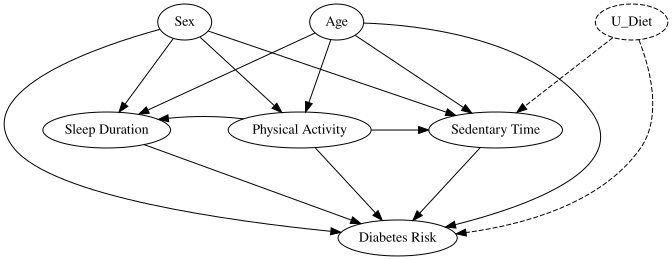

In [6]:
dot = graphviz.Digraph()
dot.attr(nodesep='0.8', ranksep='1.0')

with dot.subgraph() as top:
    top.attr(rank='same')
    top.node('Sex')
    top.node('Age')
    top.node('U_Diet', style='dashed')

with dot.subgraph() as middle:
    middle.attr(rank='same')
    middle.node('Sleep Duration')
    middle.node('Physical Activity')
    middle.node('Sedentary Time')

with dot.subgraph() as bottom:
    bottom.attr(rank='same')
    bottom.node('Diabetes Risk')

# vertical edges
edges = [
    ('Age', 'Sedentary Time'), ('Age', 'Physical Activity'), ('Age', 'Sleep Duration'),
    ('Sex', 'Sedentary Time'), ('Sex', 'Physical Activity'), ('Sex', 'Sleep Duration'),
    ('Age', 'Diabetes Risk'), ('Sex', 'Diabetes Risk'),
    ('Sedentary Time', 'Diabetes Risk'), ('Physical Activity', 'Diabetes Risk'), ('Sleep Duration', 'Diabetes Risk')
]

for edge in edges:
    dot.edge(edge[0], edge[1])

# horizontal edges
dot.edge('Sleep Duration', 'Physical Activity', style='invis')
dot.edge('Physical Activity', 'Sleep Duration', constraint='false')
dot.edge('Physical Activity', 'Sedentary Time')

# unobserved edges with dashed line
dot.edge('U_Diet', 'Sedentary Time', style='dashed')
dot.edge('U_Diet', 'Diabetes Risk', style='dashed')

dot

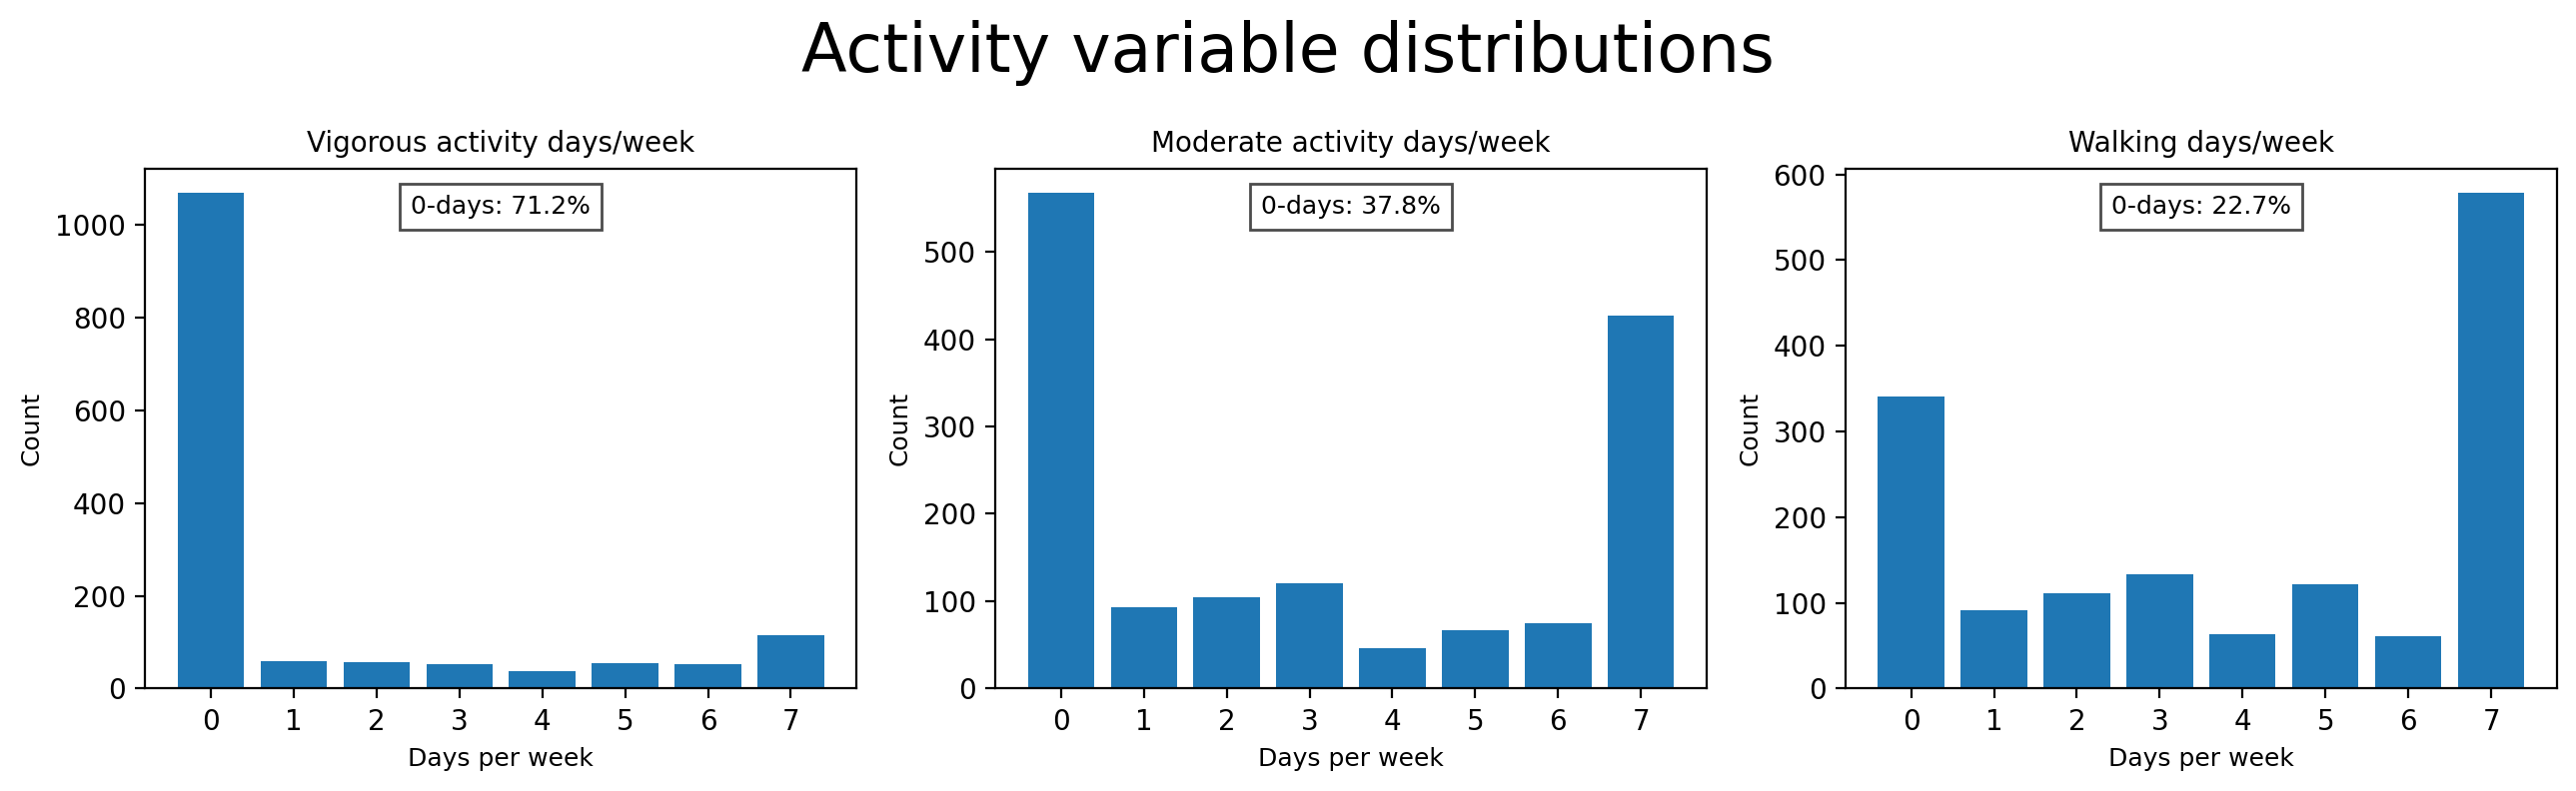

In [7]:
activity_vars = ["vig_days", "mod_days", "walk_days"]
act_labels = {
    "vig_days":  "Vigorous activity days/week",
    "mod_days":  "Moderate activity days/week",
    "walk_days": "Walking days/week",
}

fig, axes = subplots(1, 3, figsize=(13, 4))
fig.suptitle("Activity variable distributions", fontsize=24)

for ax, var in zip(axes, activity_vars):
    counts = model_df[var].value_counts().sort_index()
    pct_zero = (model_df[var] == 0).mean() * 100

    ax.bar(counts.index, counts.values)
    ax.set_title(act_labels[var], fontsize=10)
    ax.set_xlabel("Days per week", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.set_xticks(range(0, 8))
    ax.text(0.5, 0.95, f"0-days: {pct_zero:.1f}%",
        transform=ax.transAxes, ha="center", va="top",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.7))

tight_layout()

In [8]:
print("=== ZERO-INFLATION SUMMARY ===")
for var in activity_vars:
    print(f"  {var:12s}: {(model_df[var]==0).mean()*100:.1f}% zeros  "
          f"median={model_df[var].median():.0f}  mean={model_df[var].mean():.1f}")

print("\n=== SPEARMAN CORRELATIONS ===")
pairs = [("vig_days","mod_days"), ("vig_days","walk_days"), ("mod_days","walk_days")]
for a, b in pairs:
    r, p = stats.spearmanr(model_df[a], model_df[b])
    print(f"  {a} vs {b}: r = {r:.3f}, p = {p:.4f}")

print("\n=== VIF ===")
model_df["age_c_tmp"]  = model_df["age"] - model_df["age"].mean()
model_df["sed_c_tmp"]  = model_df["sedentary_hours"] - model_df["sedentary_hours"].mean()
X_vif = sm.add_constant(model_df[["age_c_tmp", "female", "sleep_cat",
                                    "sed_c_tmp", "vig_days", "mod_days", "walk_days"]])
vif_data = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
})
print(vif_data.to_string(index=False))

=== ZERO-INFLATION SUMMARY ===
  vig_days    : 71.2% zeros  median=0  mean=1.3
  mod_days    : 37.8% zeros  median=2  mean=3.1
  walk_days   : 22.7% zeros  median=5  mean=4.0

=== SPEARMAN CORRELATIONS ===
  vig_days vs mod_days: r = 0.057, p = 0.0276
  vig_days vs walk_days: r = 0.107, p = 0.0000
  mod_days vs walk_days: r = 0.101, p = 0.0001

=== VIF ===
 variable       VIF
    const 13.267199
age_c_tmp  1.015512
   female  1.134370
sleep_cat  1.012338
sed_c_tmp  1.051907
 vig_days  1.141724
 mod_days  1.049166
walk_days  1.039911


/tmp/ipykernel_12583/3962670769.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  tight_layout()


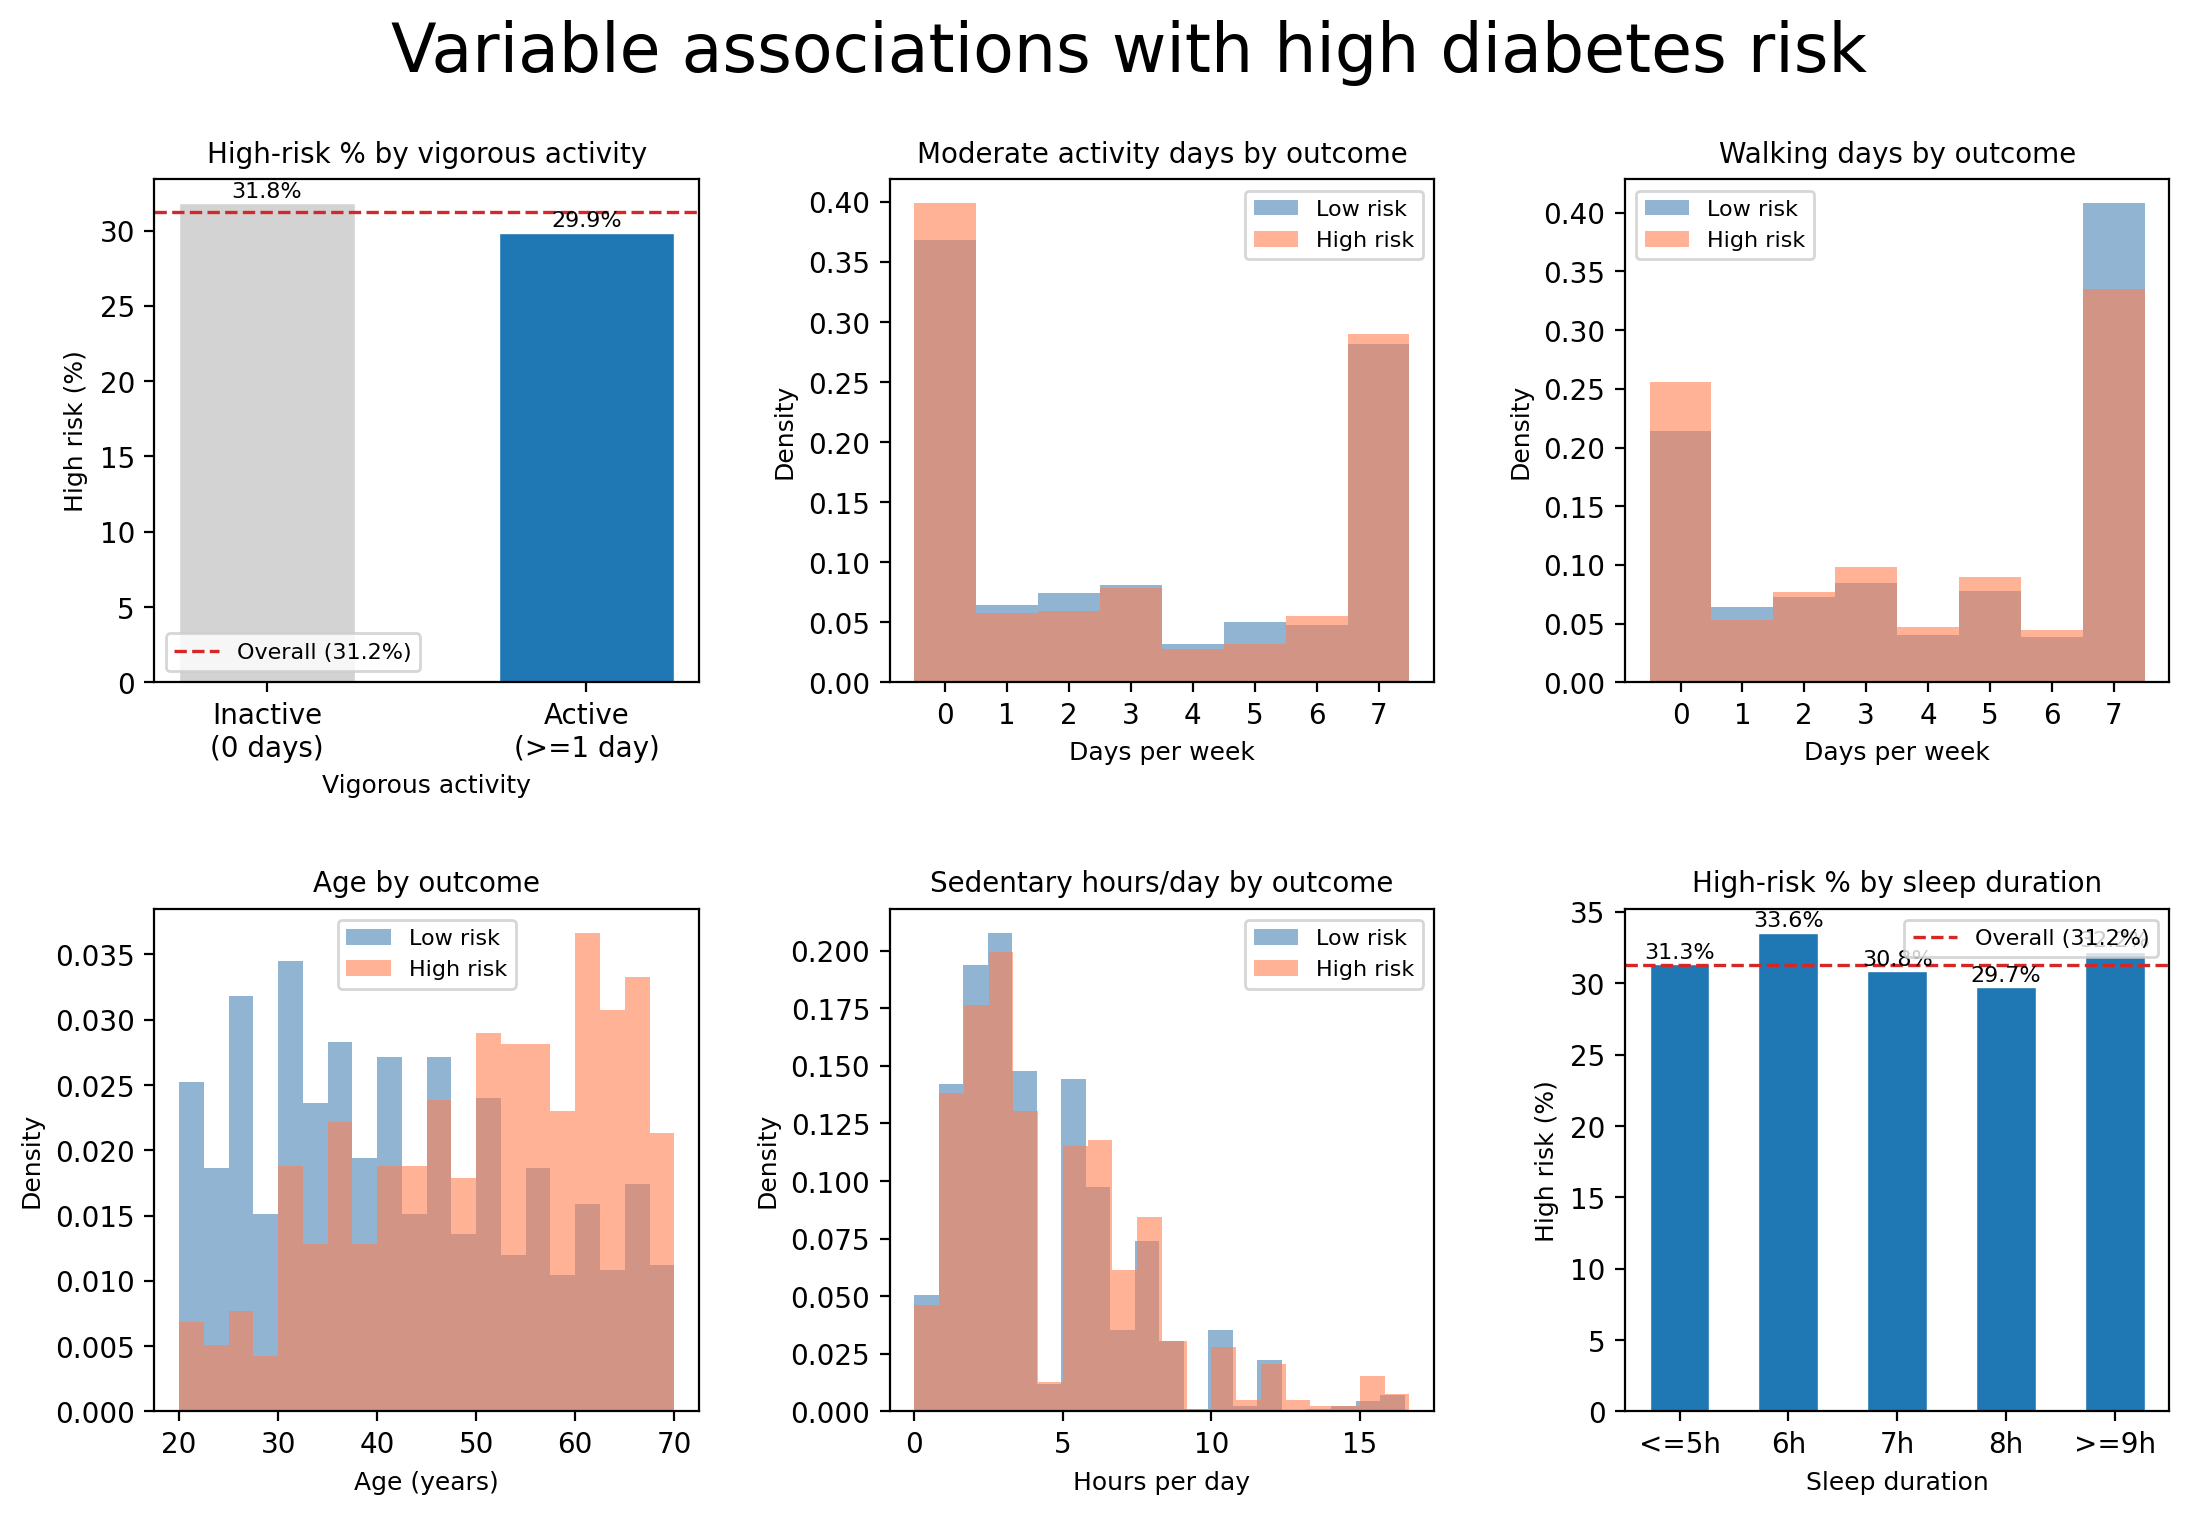

In [9]:
fig2 = figure(figsize=(13, 8))
gs2  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)
fig2.suptitle("Variable associations with high diabetes risk", fontsize=24)

overall_risk_pct = model_df["high_risk"].mean() * 100

def hist_by_outcome(ax, var, title, xlabel, bins=20):
    for val, col, lbl in [(0, "steelblue", "Low risk"), (1, "coral", "High risk")]:
        ax.hist(model_df[model_df["high_risk"] == val][var],
                bins=bins, alpha=0.6, color=col, label=lbl, density=True)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)

def prop_bar(ax, categories, values, title, xlabel, bar_color="C0"):
    ax.cla()
    for i, (cat, val) in enumerate(zip(categories, values)):
        col = bar_color[i] if isinstance(bar_color, list) else bar_color
        ax.bar(cat, val, color=col, edgecolor="white", linewidth=0.5, width=0.55)
        ax.text(i, val + 0.4, f"{val:.1f}%", ha="center", fontsize=8)
    ax.axhline(overall_risk_pct, color="C3", linewidth=1.2,
               linestyle="--", label=f"Overall ({overall_risk_pct:.1f}%)")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("High risk (%)", fontsize=9)
    ax.legend(fontsize=8)

ax00 = fig2.add_subplot(gs2[0, 0])
risk_vig = model_df.groupby("vig_active")["high_risk"].mean() * 100
prop_bar(ax00, ["Inactive\n(0 days)", "Active\n(>=1 day)"],
         risk_vig.values, "High-risk % by vigorous activity",
         "Vigorous activity", bar_color=["lightgray", "C0"])

ax01 = fig2.add_subplot(gs2[0, 1])
hist_by_outcome(ax01, "mod_days", "Moderate activity days by outcome",
                "Days per week", bins=np.arange(-0.5, 8.5, 1))
ax01.set_xticks(range(0, 8))

ax02 = fig2.add_subplot(gs2[0, 2])
hist_by_outcome(ax02, "walk_days", "Walking days by outcome",
                "Days per week", bins=np.arange(-0.5, 8.5, 1))
ax02.set_xticks(range(0, 8))

ax10 = fig2.add_subplot(gs2[1, 0])
hist_by_outcome(ax10, "age", "Age by outcome", "Age (years)", bins=20)

ax11 = fig2.add_subplot(gs2[1, 1])
hist_by_outcome(ax11, "sedentary_hours", "Sedentary hours/day by outcome",
                "Hours per day", bins=20)

ax12 = fig2.add_subplot(gs2[1, 2])
risk_sleep = (model_df.groupby("sleep_label")["high_risk"]
                       .mean().reindex(sleep_order) * 100)
prop_bar(ax12, sleep_order, risk_sleep.values,
         "High-risk % by sleep duration", "Sleep duration")

tight_layout()

In [10]:
y = model_df["high_risk"]

def fit_logit_and_report(X, y):
    X_const = sm.add_constant(X)
    result  = sm.Logit(y, X_const).fit(disp=False)
    print(f"\n=== LOGISTIC REGRESSION RESULTS ===")
    print(result.summary())
    conf = result.conf_int()
    conf.columns = ["2.5%", "97.5%"]
    or_table = pd.DataFrame({
        "variable": result.params.index,
        "coef": result.params.values,
        "odds_ratio": np.exp(result.params.values),
        "ci_2.5": np.exp(conf["2.5%"].values),
        "ci_97.5": np.exp(conf["97.5%"].values),
        "p_value": result.pvalues.values,
    })
    return result, or_table

In [11]:
lr = pd.concat([
    model_df[["age_c", "female", "sedentary_hours_c", "vig_active", "mod_days", "walk_days"]], sleep_dummies], axis=1)
result, or_table = fit_logit_and_report(lr, y)


=== LOGISTIC REGRESSION RESULTS ===
                           Logit Regression Results                           
Dep. Variable:              high_risk   No. Observations:                 1501
Model:                          Logit   Df Residuals:                     1490
Method:                           MLE   Df Model:                           10
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                 0.07860
Time:                        23:05:14   Log-Likelihood:                -858.93
converged:                       True   LL-Null:                       -932.20
Covariance Type:            nonrobust   LLR p-value:                 1.917e-26
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.6815      0.174     -3.922      0.000      -1.022      -0.341
age_c                 0.0493      0.004     11.026      0.000       0.041

$$
Y_i \sim \mathrm{Bernoulli}(p_i)
$$

$$
\mathrm{logit}(p_i)
=
\beta_0
+
\beta_{\mathrm{age}}\,\mathrm{age}_i
+
\beta_{\mathrm{sex}}\,\mathrm{sex}_i
+
\beta_{\mathrm{sed}}\,\mathrm{sedentary}_i
+
\beta_{\mathrm{vig}}\,\mathrm{vigorous}_i
+
\beta_{\mathrm{walk}}\,\mathrm{walking}_i
+
\text{sleep terms}
$$

$$
\beta_0 \sim \mathrm{Normal}(0,1.5),
\qquad
\beta_j \sim \mathrm{Normal}(0,0.5)
$$


$$\begin{align*}
Y_i &\sim \text{Bernoulli}(p_i) \\
\text{logit}(p_i) &= \beta_0
  + \beta_{\text{age}} \cdot \text{age}_i
  + \beta_{\text{female}} \cdot \text{female}_i
  + \beta_{\text{sed}} \cdot \text{sedentary_hours}_i
  + \beta_{\text{vig}} \cdot \text{vig_active}_i
  + \beta_{\text{walk}} \cdot \text{walk_days}_i \\
&\quad
  + \beta_{s1} \cdot \text{sleep}_{\leq5h,i}
  + \beta_{s2} \cdot \text{sleep}_{6h,i}
  + \beta_{s3} \cdot \text{sleep}_{8h,i}
  + \beta_{s4} \cdot \text{sleep}_{\geq9h,i} \\
\beta_0 &\sim \text{Normal}(0,\ 1.5) \\
\beta_{\text{age}} &\sim \text{Normal}(0,\ 0.5) \\
\beta_{\text{female}} &\sim \text{Normal}(0,\ 0.5) \\
\beta_{\text{sed}} &\sim \text{Normal}(0,\ 0.5) \\
\beta_{\text{vig}} &\sim \text{Normal}(0,\ 0.5) \\
\beta_{\text{walk}} &\sim \text{Normal}(0,\ 0.5) \\
\beta_{s1} &\sim \text{Normal}(0,\ 0.5) \\
\beta_{s2} &\sim \text{Normal}(0,\ 0.5) \\
\beta_{s3} &\sim \text{Normal}(0,\ 0.5) \\
\beta_{s4} &\sim \text{Normal}(0,\ 0.5)
\end{align*}$$


Text(0, 0.5, 'P(high risk)')

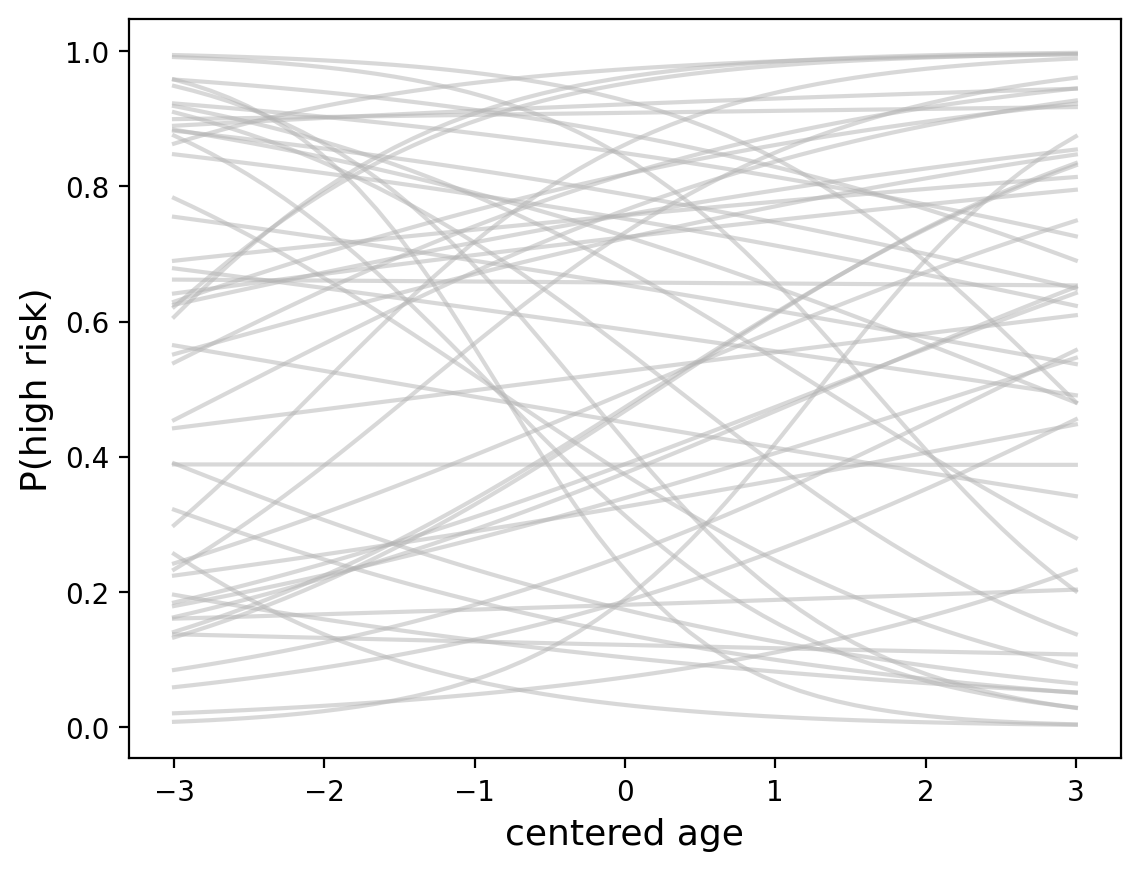

In [12]:
# Prior check
N_lines   = 50
age_range = linspace(-3, 3, 50)

beta_0_s   = normal(0, 1.5, N_lines)
beta_age_s = normal(0, 0.5, N_lines)

p_age = 1 / (1 + exp(-(beta_0_s[None, :] + beta_age_s[None, :] * age_range[:, None])))
plot(age_range, p_age, '0.7', alpha=0.5)
xlabel('centered age', fontsize=13)
ylabel('P(high risk)', fontsize=13)

Text(0, 0.5, 'P(high risk)')

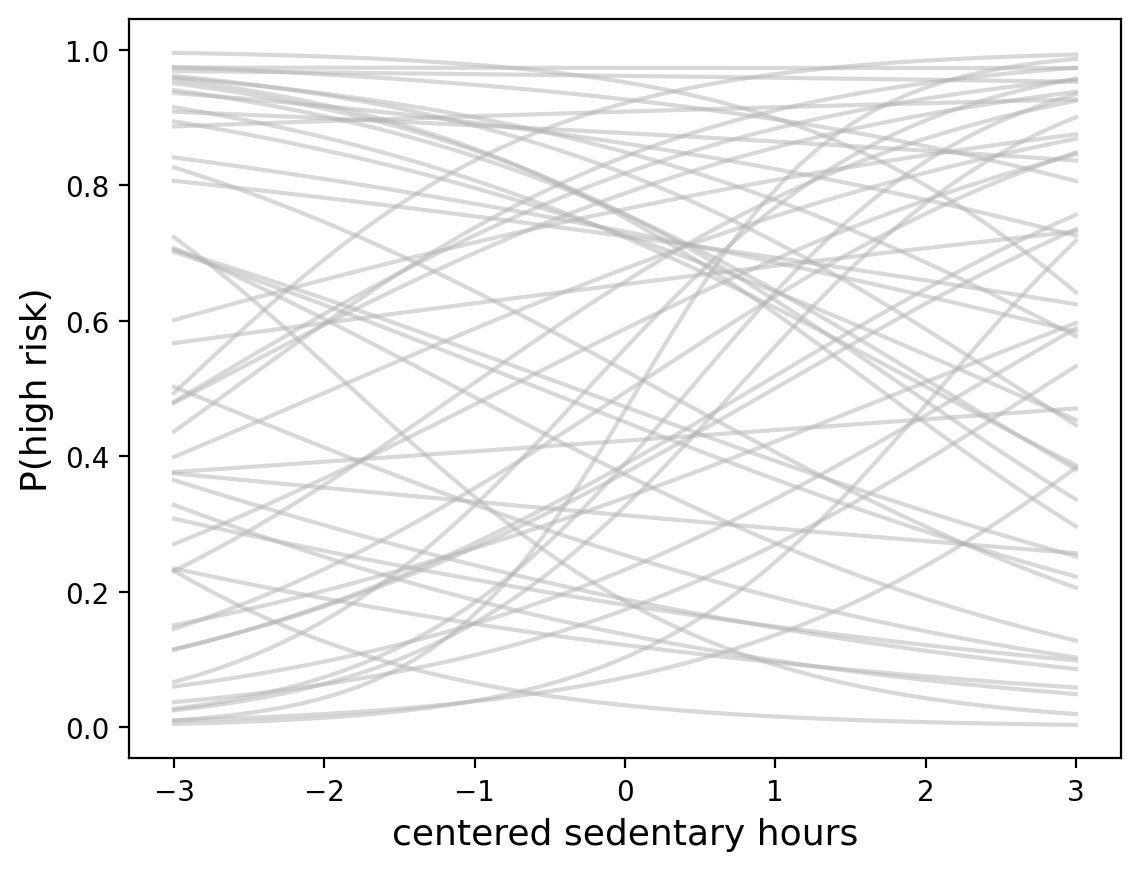

In [13]:
sed_range  = linspace(-3, 3, 50)
beta_sed_s = normal(0, 0.5, N_lines)

p_sed = 1 / (1 + exp(-(beta_0_s[None, :] + beta_sed_s[None, :] * sed_range[:, None])))
plot(sed_range, p_sed, '0.7', alpha=0.5)
xlabel('centered sedentary hours', fontsize=13)
ylabel('P(high risk)', fontsize=13)

Text(0, 0.5, 'P(high risk)')

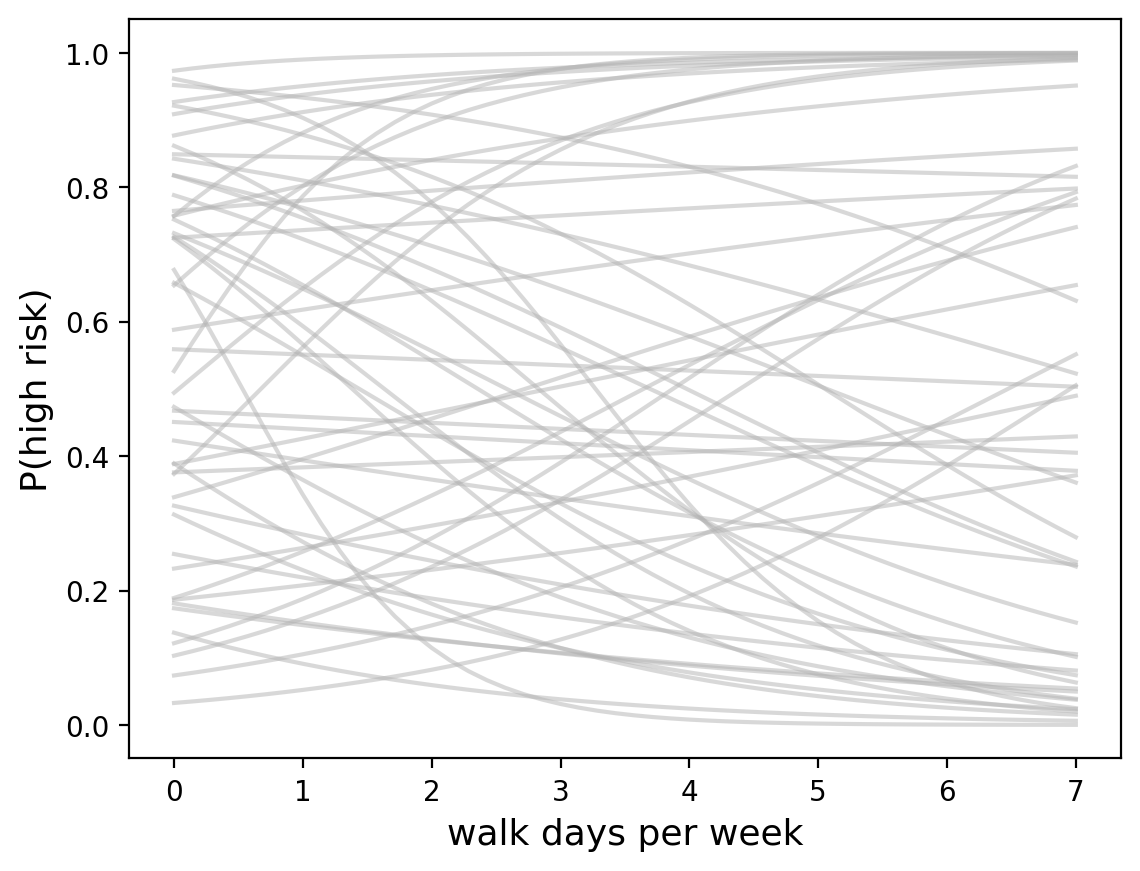

In [14]:
walk_range  = linspace(0, 7, 50)
beta_walk_s = normal(0, 0.5, N_lines)

p_walk = 1 / (1 + exp(-(beta_0_s[None, :] + beta_walk_s[None, :] * walk_range[:, None])))
plot(walk_range, p_walk, '0.7', alpha=0.5)
xlabel('walk days per week', fontsize=13)
ylabel('P(high risk)', fontsize=13)

In [15]:
with pm.Model() as diabetes_model:
    beta_0 = pm.Normal('beta_0', mu=0, sigma=1.5)
    beta_age = pm.Normal('beta_age', mu=0, sigma=0.5)
    beta_fem = pm.Normal('beta_fem', mu=0, sigma=0.5)
    beta_sed = pm.Normal('beta_sed', mu=0, sigma=0.5)
    beta_vig = pm.Normal('beta_vig', mu=0, sigma=0.5)
    beta_walk = pm.Normal('beta_walk', mu=0, sigma=0.5)
    beta_s1 = pm.Normal('beta_s1', mu=0, sigma=0.5)
    beta_s2 = pm.Normal('beta_s2', mu=0, sigma=0.5)
    beta_s3 = pm.Normal('beta_s3', mu=0, sigma=0.5)
    beta_s4 = pm.Normal('beta_s4', mu=0, sigma=0.5)
    _logit_p = (beta_0 + beta_age * model_df["age_c"] + beta_fem * model_df["female"] + beta_sed * model_df["sedentary_hours_c"]
                + beta_vig * model_df["vig_active"] + beta_walk * model_df["walk_days"] + beta_s1 * sleep_dummies["sleep_<=5h"]
                + beta_s2 * sleep_dummies["sleep_6h"] + beta_s3 * sleep_dummies["sleep_8h"] + beta_s4 * sleep_dummies["sleep_>=9h"])
    logit_p = pm.Deterministic('logit_p', _logit_p)
    Y_obs = pm.Bernoulli('Y_obs', logit_p=logit_p, observed=model_df["high_risk"])
    _diabetes_posterior = pm.sample(2000, tune=1000, chains=4)
diabetes_posterior = _diabetes_posterior.posterior.to_dataframe()
diabetes_posterior

Output()

beta_0  beta_age  beta_fem   beta_s1   beta_s2  \
chain draw logit_p_dim_0                                                    
0     0    0             -0.78598  0.054006 -0.068865  0.009826  0.092632   
           1             -0.78598  0.054006 -0.068865  0.009826  0.092632   
           2             -0.78598  0.054006 -0.068865  0.009826  0.092632   
           3             -0.78598  0.054006 -0.068865  0.009826  0.092632   
           4             -0.78598  0.054006 -0.068865  0.009826  0.092632   
...                           ...       ...       ...       ...       ...   
3     1999 1496          -0.36304  0.051007 -0.397654 -0.391511  0.100979   
           1497          -0.36304  0.051007 -0.397654 -0.391511  0.100979   
           1498          -0.36304  0.051007 -0.397654 -0.391511  0.100979   
           1499          -0.36304  0.051007 -0.397654 -0.391511  0.100979   
           1500          -0.36304  0.051007 -0.397654 -0.391511  0.100979   

                           beta_s3   beta_s4  beta_sed  beta_vig  beta_walk  \
chain draw logit_p_dim_0                                                      
0     0    0             -0.195292  0.022327  0.046936  0.145897  -0.017289   
           1             -0.195292  0.022327  0.046936  0.145897  -0.017289   
           2             -0.195292  0.022327  0.046936  0.145897  -0.017289   
           3             -0.195292  0.022327  0.046936  0.145897  -0.017289   
           4             -0.195292  0.022327  0.046936  0.145897  -0.017289   
...                            ...       ...       ...       ...        ...   
3     1999 1496          -0.093057 -0.233922  0.040792  0.104294  -0.046265   
           1497          -0.093057 -0.233922  0.040792  0.104294  -0.046265   
           1498          -0.093057 -0.233922  0.040792  0.104294  -0.046265   
           1499          -0.093057 -0.233922  0.040792  0.104294  -0.046265   
           1500          -0.093057 -0.233922  0.040792  0.104294  -0.046265   

                           logit_p  
chain draw logit_p_dim_0            
0     0    0             -0.256776  
           1             -2.214243  
           2             -0.910194  
           3              0.346489  
           4             -0.485450  
...                            ...  
3     1999 1496          -0.035466  
           1497          -0.893099  
           1498          -0.708957  
           1499          -1.545244  
           1500          -0.749018  

[12008000 rows x 11 columns]

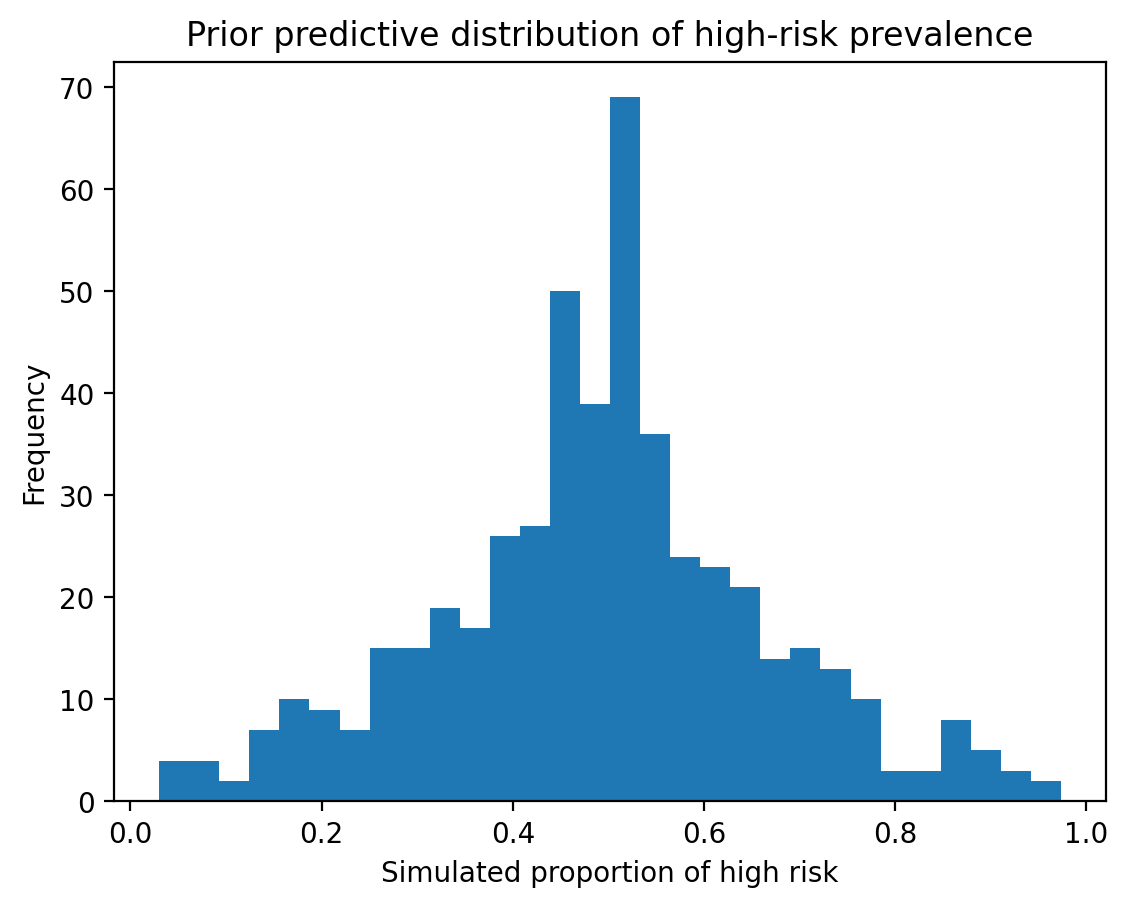

In [16]:
with diabetes_model:
    prior_pred = pm.sample_prior_predictive(samples=500)

y_prior = prior_pred.prior_predictive["Y_obs"]
y_prior_mean = y_prior.values.mean(axis=2).flatten()

plt.hist(y_prior_mean, bins=30)
plt.xlabel("Simulated proportion of high risk")
plt.ylabel("Frequency")
plt.title("Prior predictive distribution of high-risk prevalence")
plt.show()

Text(0.5, 1.0, '95% HDI')

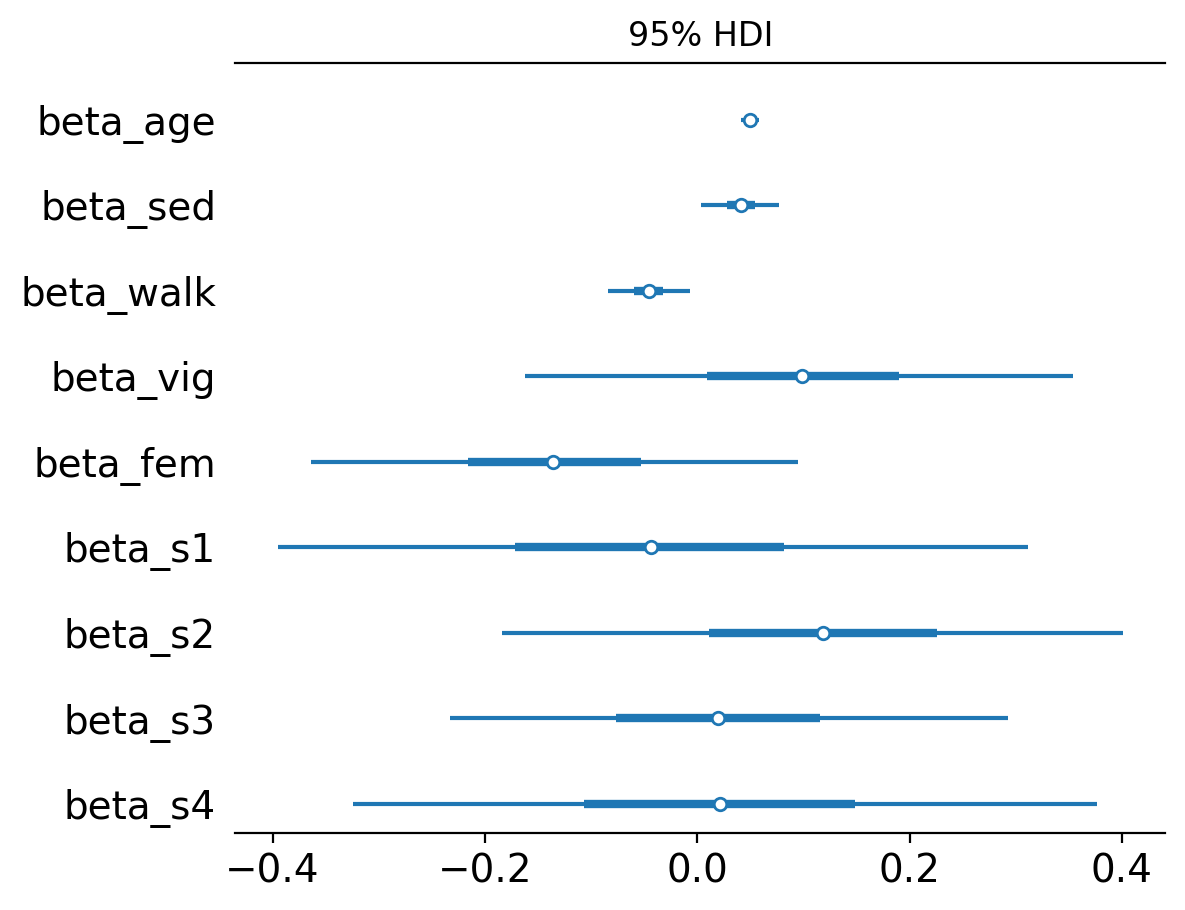

In [17]:
az.plot_forest(_diabetes_posterior, var_names=['beta_age', 'beta_sed', 'beta_walk', 'beta_vig', 'beta_fem', 'beta_s1', 'beta_s2', 'beta_s3', 'beta_s4'], combined=True, figsize=[6, 5])
title('95% HDI', fontsize=12)

In [18]:
print(az.summary(_diabetes_posterior, var_names=["~logit_p"], hdi_prob=0.95).to_string())

            mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta_0    -0.675  0.162    -0.999     -0.364      0.003    0.002    3899.0    4595.0    1.0
beta_age   0.050  0.004     0.041      0.058      0.000    0.000    7815.0    5071.0    1.0
beta_fem  -0.135  0.123    -0.364      0.117      0.002    0.001    5980.0    5813.0    1.0
beta_s1   -0.045  0.188    -0.406      0.331      0.002    0.002    6267.0    5628.0    1.0
beta_s2    0.118  0.156    -0.193      0.413      0.002    0.001    5436.0    6197.0    1.0
beta_s3    0.019  0.141    -0.251      0.297      0.002    0.001    5126.0    5790.0    1.0
beta_s4    0.022  0.188    -0.356      0.376      0.002    0.002    6964.0    6453.0    1.0
beta_sed   0.041  0.020     0.004      0.080      0.000    0.000    8990.0    6604.0    1.0
beta_vig   0.099  0.136    -0.162      0.370      0.002    0.001    7257.0    6722.0    1.0
beta_walk -0.046  0.021    -0.085     -0.004      0.000    0.000    6402.0    60

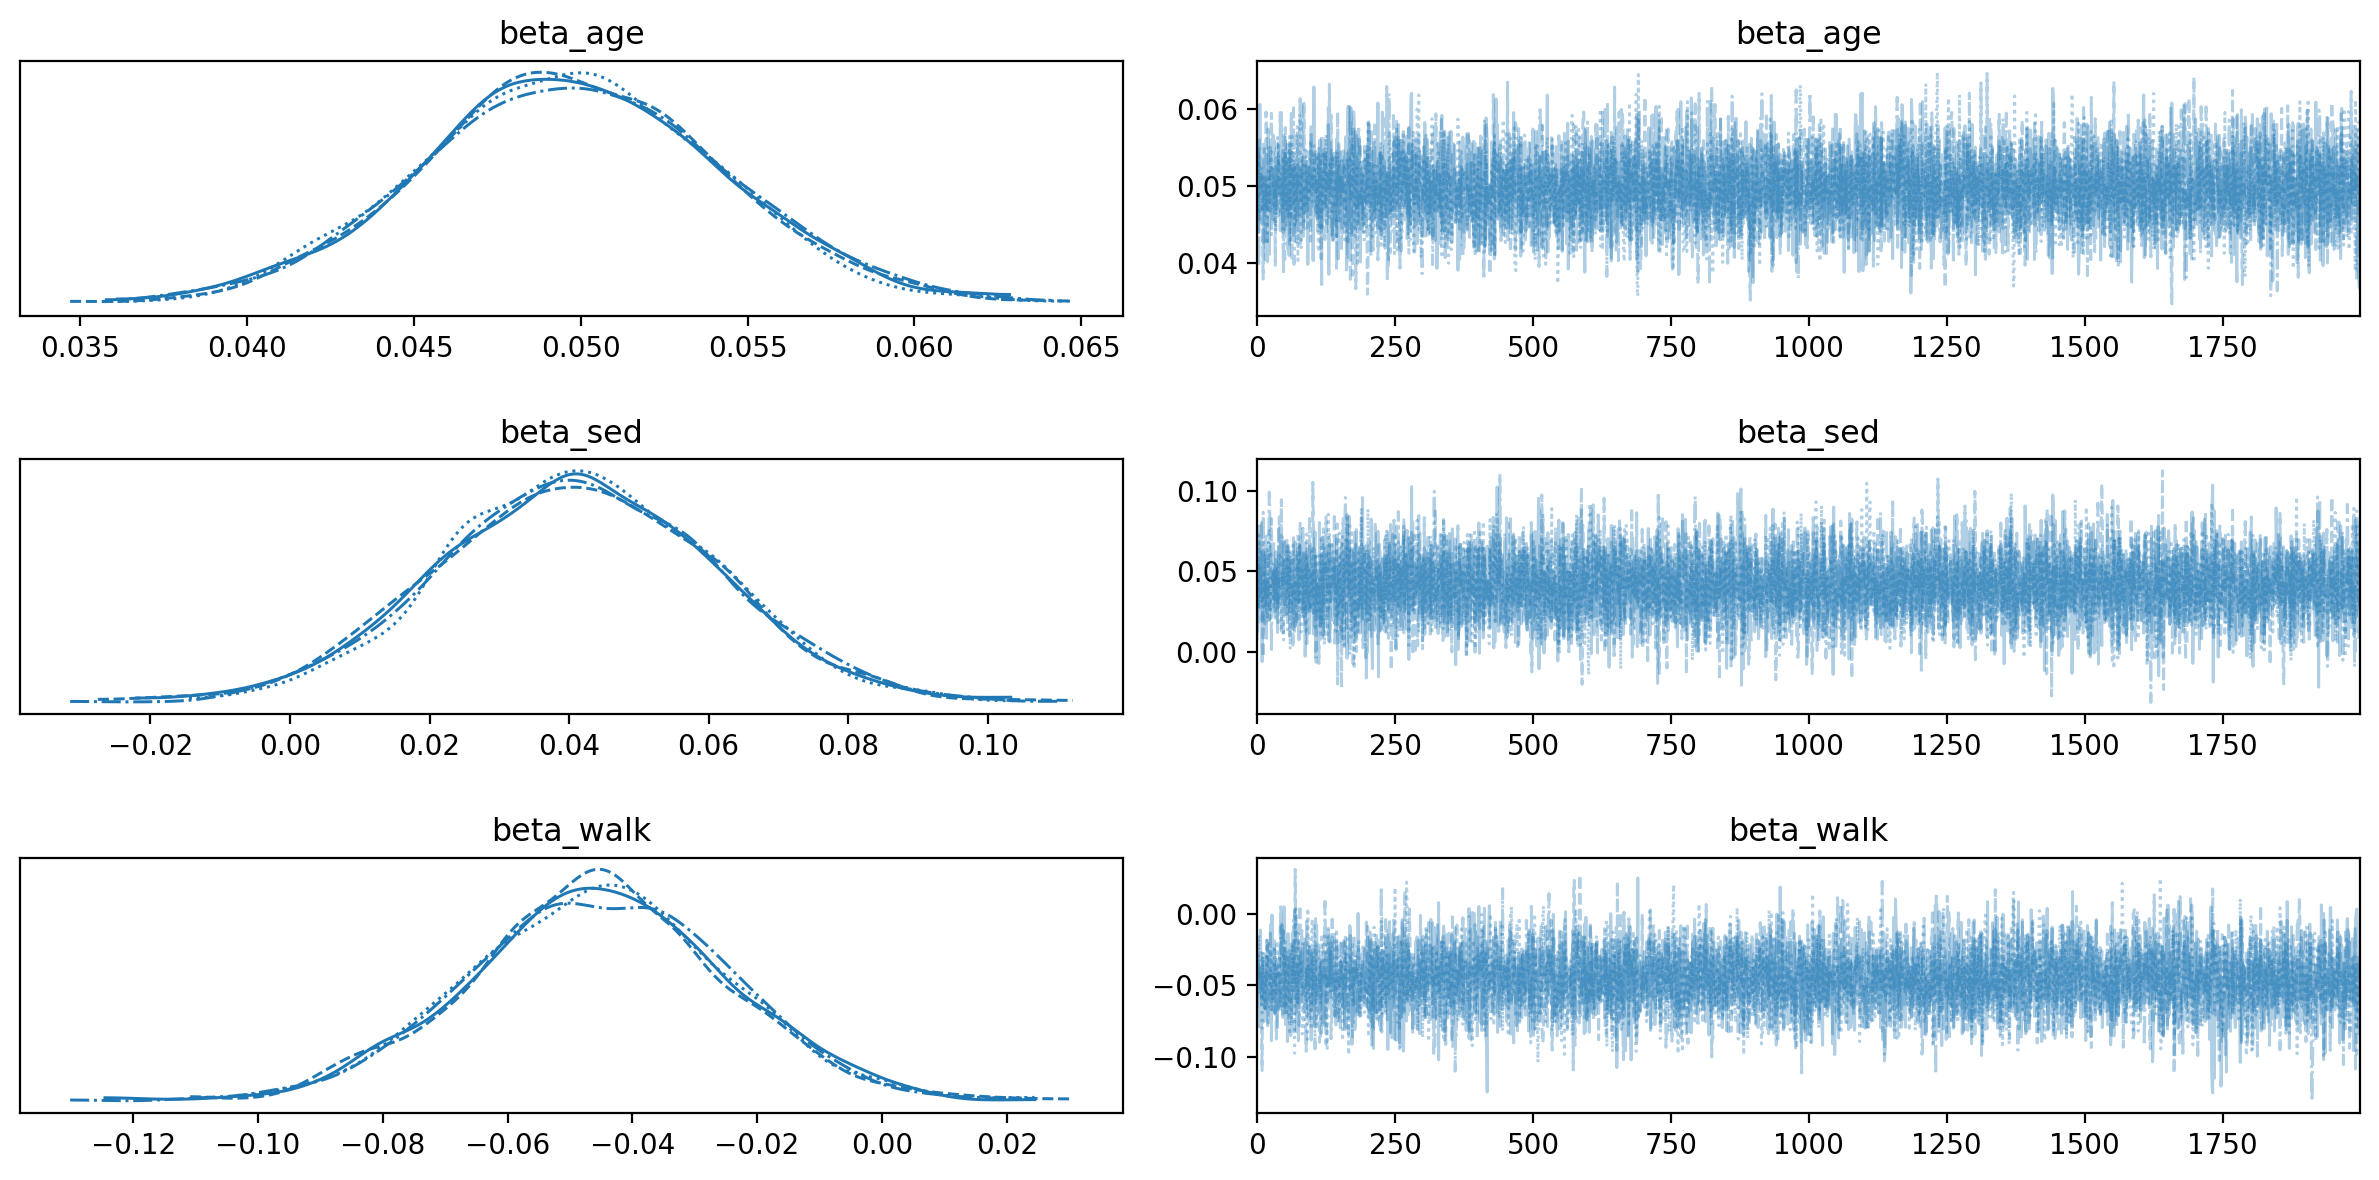

In [19]:
az.plot_trace(_diabetes_posterior, var_names=['beta_age', 'beta_sed', 'beta_walk'], compact=True)
plt.tight_layout(h_pad=2)

Output()

<Axes: xlabel='Y_obs'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


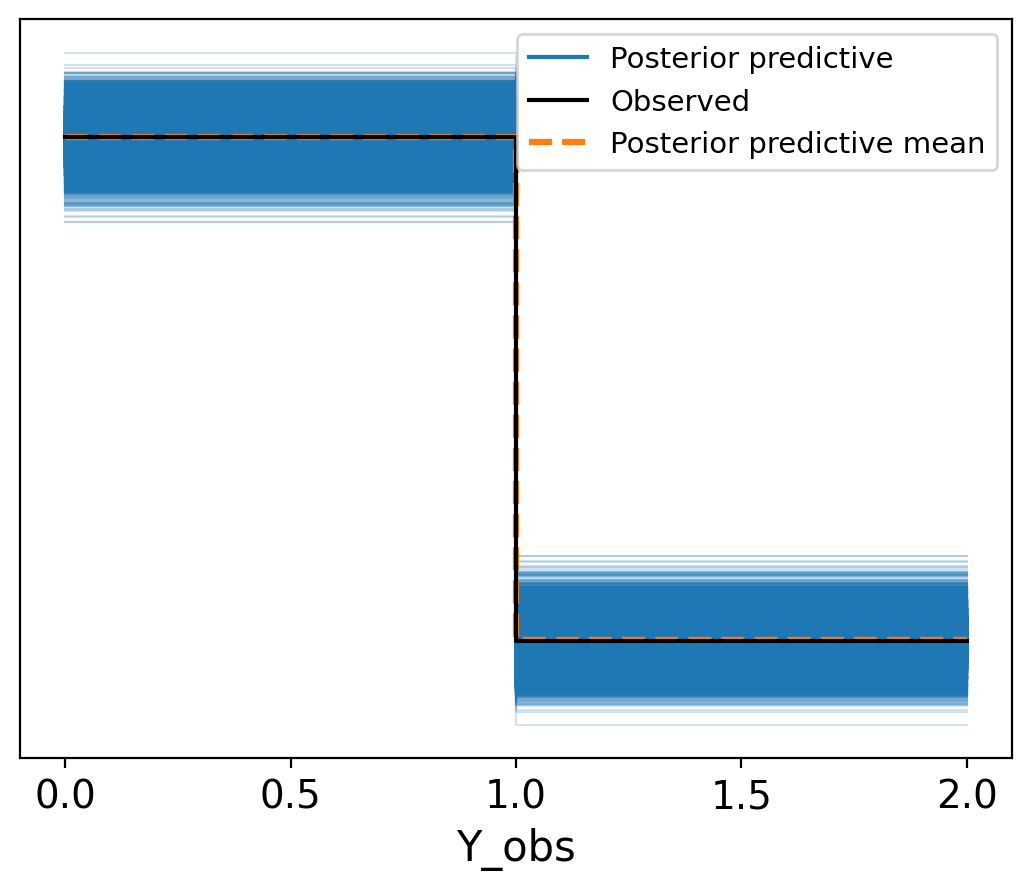

In [20]:
with diabetes_model:
    ppc = pm.sample_posterior_predictive(_diabetes_posterior)
az.plot_ppc(ppc)

In [21]:
"""
fig = figure(1, [15, 4])

for i, (param, label) in enumerate([('beta_age',  'Age'),
                                     ('beta_sed',  'Sedentary hours'),
                                     ('beta_walk', 'Walk days')]):
    fig.add_subplot(1, 3, i+1)
    sns.kdeplot(diabetes_posterior[param], fill=True, bw_adjust=3)
    axvline(diabetes_posterior[param].mean(), color='k',
            linewidth=1.5, linestyle='-', label='mean')
    xlabel('log-odds', fontsize=12)
    ylabel('density', fontsize=12)
    title(f'Posterior density: {label}', fontsize=12)
    legend(fontsize=9)

tight_layout()
"""

"\nfig = figure(1, [15, 4])\n\nfor i, (param, label) in enumerate([('beta_age',  'Age'),\n                                     ('beta_sed',  'Sedentary hours'),\n                                     ('beta_walk', 'Walk days')]):\n    fig.add_subplot(1, 3, i+1)\n    sns.kdeplot(diabetes_posterior[param], fill=True, bw_adjust=3)\n    axvline(diabetes_posterior[param].mean(), color='k',\n            linewidth=1.5, linestyle='-', label='mean')\n    xlabel('log-odds', fontsize=12)\n    ylabel('density', fontsize=12)\n    title(f'Posterior density: {label}', fontsize=12)\n    legend(fontsize=9)\n\ntight_layout()\n"

## Comparison

In [22]:
# Bayesian summary
bayes_summary = az.summary(_diabetes_posterior, var_names=["~logit_p"], hdi_prob=0.95)

# Map: frequentist variable name -> bayesian parameter name
name_map = {
    'const':             'beta_0',
    'age_c':             'beta_age',
    'female':            'beta_fem',
    'sedentary_hours_c': 'beta_sed',
    'vig_active':        'beta_vig',
    'walk_days':         'beta_walk',
    'sleep_<=5h':        'beta_s1',
    'sleep_6h':          'beta_s2',
    'sleep_8h':          'beta_s3',
    'sleep_>=9h':        'beta_s4',
}

rows = []
for var in result.params.index:
    row = {
        'Variable': var,
        'Freq_coef': f"{result.params[var]:.4f}",
        'Freq_95CI': f"[{result.conf_int().loc[var, 0]:.3f}, {result.conf_int().loc[var, 1]:.3f}]",
        'Freq_p': f"{result.pvalues[var]:.4f}" if result.pvalues[var] >= 0.001 else "<0.001",
    }
    bayes_name = name_map.get(var)
    if bayes_name and bayes_name in bayes_summary.index:
        b = bayes_summary.loc[bayes_name]
        row['Bayes_mean'] = f"{b['mean']:.4f}"
        row['Bayes_95HDI'] = f"[{b['hdi_2.5%']:.3f}, {b['hdi_97.5%']:.3f}]"
    else:
        row['Bayes_mean'] = '—'
        row['Bayes_95HDI'] = '—'
    rows.append(row)

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

         Variable Freq_coef        Freq_95CI Freq_p Bayes_mean      Bayes_95HDI
            const   -0.6815 [-1.022, -0.341] <0.001    -0.6750 [-0.999, -0.364]
            age_c    0.0493   [0.041, 0.058] <0.001     0.0500   [0.041, 0.058]
           female   -0.1383  [-0.392, 0.115] 0.2843    -0.1350  [-0.364, 0.117]
sedentary_hours_c    0.0409   [0.003, 0.079] 0.0368     0.0410   [0.004, 0.080]
       vig_active    0.1071  [-0.169, 0.383] 0.4468     0.0990  [-0.162, 0.370]
         mod_days   -0.0001  [-0.039, 0.039] 0.9941          —                —
        walk_days   -0.0451 [-0.086, -0.005] 0.0287    -0.0460 [-0.085, -0.004]
         sleep_6h    0.1369  [-0.202, 0.476] 0.4285     0.1180  [-0.193, 0.413]
         sleep_8h    0.0291  [-0.278, 0.336] 0.8525     0.0190  [-0.251, 0.297]
       sleep_<=5h   -0.0377  [-0.451, 0.376] 0.8582    -0.0450  [-0.406, 0.331]
       sleep_>=9h    0.0392  [-0.372, 0.451] 0.8518     0.0220  [-0.356, 0.376]


In [23]:
key_betas = ['beta_age','beta_fem','beta_sed','beta_vig','beta_walk',
             'beta_s1','beta_s2','beta_s3','beta_s4']

for var in key_betas:
    samples = diabetes_posterior[var]
    if var in ['beta_fem', 'beta_walk']:
        prob = (samples < 0).mean()
        print(f"P({var} < 0) = {prob:.3f}  (protective)")
    else:
        prob = (samples > 0).mean()
        print(f"P({var} > 0) = {prob:.3f}  (risk)")

P(beta_age > 0) = 1.000  (risk)
P(beta_fem < 0) = 0.862  (protective)
P(beta_sed > 0) = 0.983  (risk)
P(beta_vig > 0) = 0.770  (risk)
P(beta_walk < 0) = 0.986  (protective)
P(beta_s1 > 0) = 0.408  (risk)
P(beta_s2 > 0) = 0.775  (risk)
P(beta_s3 > 0) = 0.556  (risk)
P(beta_s4 > 0) = 0.548  (risk)


In [24]:
or_vars = {
    'beta_age':  'Age (per 1-year increase)',
    'beta_sed':  'Sedentary hours (per 1-hour increase)',
    'beta_walk': 'Walk days (per 1-day increase)',
    'beta_vig':  'Vigorous activity (active vs not)',
    'beta_fem':  'Female vs Male',
}

for var, label in or_vars.items():
    or_samples = np.exp(diabetes_posterior[var])
    print(f"{label}:")
    print(f"  OR = {np.median(or_samples):.3f}  "
          f"95% HDI [{np.percentile(or_samples,2.5):.3f}, {np.percentile(or_samples,97.5):.3f}]")

Age (per 1-year increase):
  OR = 1.051  95% HDI [1.042, 1.060]
Sedentary hours (per 1-hour increase):
  OR = 1.042  95% HDI [1.003, 1.083]
Walk days (per 1-day increase):
  OR = 0.956  95% HDI [0.918, 0.995]
Vigorous activity (active vs not):
  OR = 1.103  95% HDI [0.845, 1.442]
Female vs Male:
  OR = 0.873  95% HDI [0.689, 1.116]


In [25]:
# Scenario Comparisons
walk_samples = diabetes_posterior['beta_walk']
or_walk_7 = np.exp(walk_samples * 7)
print(f"Walk 7 days/week vs 0:")
print(f"  OR = {np.median(or_walk_7):.3f}  "
      f"95% HDI [{np.percentile(or_walk_7,2.5):.3f}, {np.percentile(or_walk_7,97.5):.3f}]")

sed_samples = diabetes_posterior['beta_sed']
or_sed_4 = np.exp(sed_samples * 4)
print(f"\nSedentary +4 hours vs baseline:")
print(f"  OR = {np.median(or_sed_4):.3f}  "
      f"95% HDI [{np.percentile(or_sed_4,2.5):.3f}, {np.percentile(or_sed_4,97.5):.3f}]")

age_samples = diabetes_posterior['beta_age']
or_age_10 = np.exp(age_samples * 10)
print(f"\nAge +10 years:")
print(f"  OR = {np.median(or_age_10):.3f}  "
      f"95% HDI [{np.percentile(or_age_10,2.5):.3f}, {np.percentile(or_age_10,97.5):.3f}]")

Walk 7 days/week vs 0:
  OR = 0.728  95% HDI [0.548, 0.966]

Sedentary +4 hours vs baseline:
  OR = 1.179  95% HDI [1.012, 1.375]

Age +10 years:
  OR = 1.643  95% HDI [1.506, 1.798]


## Counterfactual Intervention Simulation

In [26]:
# Extract and subsample posterior samples
np.random.seed(42)
idx = np.random.choice(len(diabetes_posterior['beta_0']), size=500, replace=False)

post = {}
for name in ['beta_0','beta_age','beta_fem','beta_sed','beta_vig','beta_walk',
             'beta_s1','beta_s2','beta_s3','beta_s4']:
    post[name] = diabetes_posterior[name].values[idx]

obs = {
    'age':  model_df["age_c"].values,
    'fem':  model_df["female"].values,
    'sed':  model_df["sedentary_hours_c"].values,
    'vig':  model_df["vig_active"].values,
    'walk': model_df["walk_days"].values,
    's1':   sleep_dummies["sleep_<=5h"].values,
    's2':   sleep_dummies["sleep_6h"].values,
    's3':   sleep_dummies["sleep_8h"].values,
    's4':   sleep_dummies["sleep_>=9h"].values,
}

In [27]:
def compute_prevalence(post, obs_override=None):
    o = {**obs, **(obs_override or {})}
    logit_p = (post['beta_0'][:, None]
               + post['beta_age'][:, None]  * o['age'][None, :]
               + post['beta_fem'][:, None]  * o['fem'][None, :]
               + post['beta_sed'][:, None]  * o['sed'][None, :]
               + post['beta_vig'][:, None]  * o['vig'][None, :]
               + post['beta_walk'][:, None] * o['walk'][None, :]
               + post['beta_s1'][:, None]   * o['s1'][None, :]
               + post['beta_s2'][:, None]   * o['s2'][None, :]
               + post['beta_s3'][:, None]   * o['s3'][None, :]
               + post['beta_s4'][:, None]   * o['s4'][None, :])
    p = 1 / (1 + np.exp(-logit_p))
    return p.mean(axis=1)

In [28]:
# Factual and counterfactual simulations
prev_factual    = compute_prevalence(post)
prev_walk7      = compute_prevalence(post, {'walk': np.full_like(obs['walk'], 7.0)})
prev_sed_minus2 = compute_prevalence(post, {'sed':  obs['sed'] - 2.0})

In [29]:
# Results
def report(label, prev):
    med = np.median(prev) * 100
    lo  = np.percentile(prev, 2.5) * 100
    hi  = np.percentile(prev, 97.5) * 100
    print(f"{label}:")
    print(f"  Prevalence = {med:.1f}%  95% CI [{lo:.1f}%, {hi:.1f}%]")

report("Factual (observed)", prev_factual)
report("Intervention 1: everyone walks 7 days/week", prev_walk7)
report("Intervention 2: everyone reduces sedentary time by 2h", prev_sed_minus2)

arr_walk = prev_factual - prev_walk7
arr_sed  = prev_factual - prev_sed_minus2

print(f"\nARR (walk 7 days): {np.median(arr_walk)*100:.1f} pp  "
      f"95% CI [{np.percentile(arr_walk,2.5)*100:.1f}, {np.percentile(arr_walk,97.5)*100:.1f}]")
print(f"ARR (sedentary -2h): {np.median(arr_sed)*100:.1f} pp  "
      f"95% CI [{np.percentile(arr_sed,2.5)*100:.1f}, {np.percentile(arr_sed,97.5)*100:.1f}]")

Factual (observed):
  Prevalence = 31.3%  95% CI [29.3%, 33.5%]
Intervention 1: everyone walks 7 days/week:
  Prevalence = 28.6%  95% CI [25.5%, 31.5%]
Intervention 2: everyone reduces sedentary time by 2h:
  Prevalence = 29.6%  95% CI [27.2%, 32.3%]

ARR (walk 7 days): 2.7 pp  95% CI [0.5, 5.2]
ARR (sedentary -2h): 1.5 pp  95% CI [0.2, 2.9]


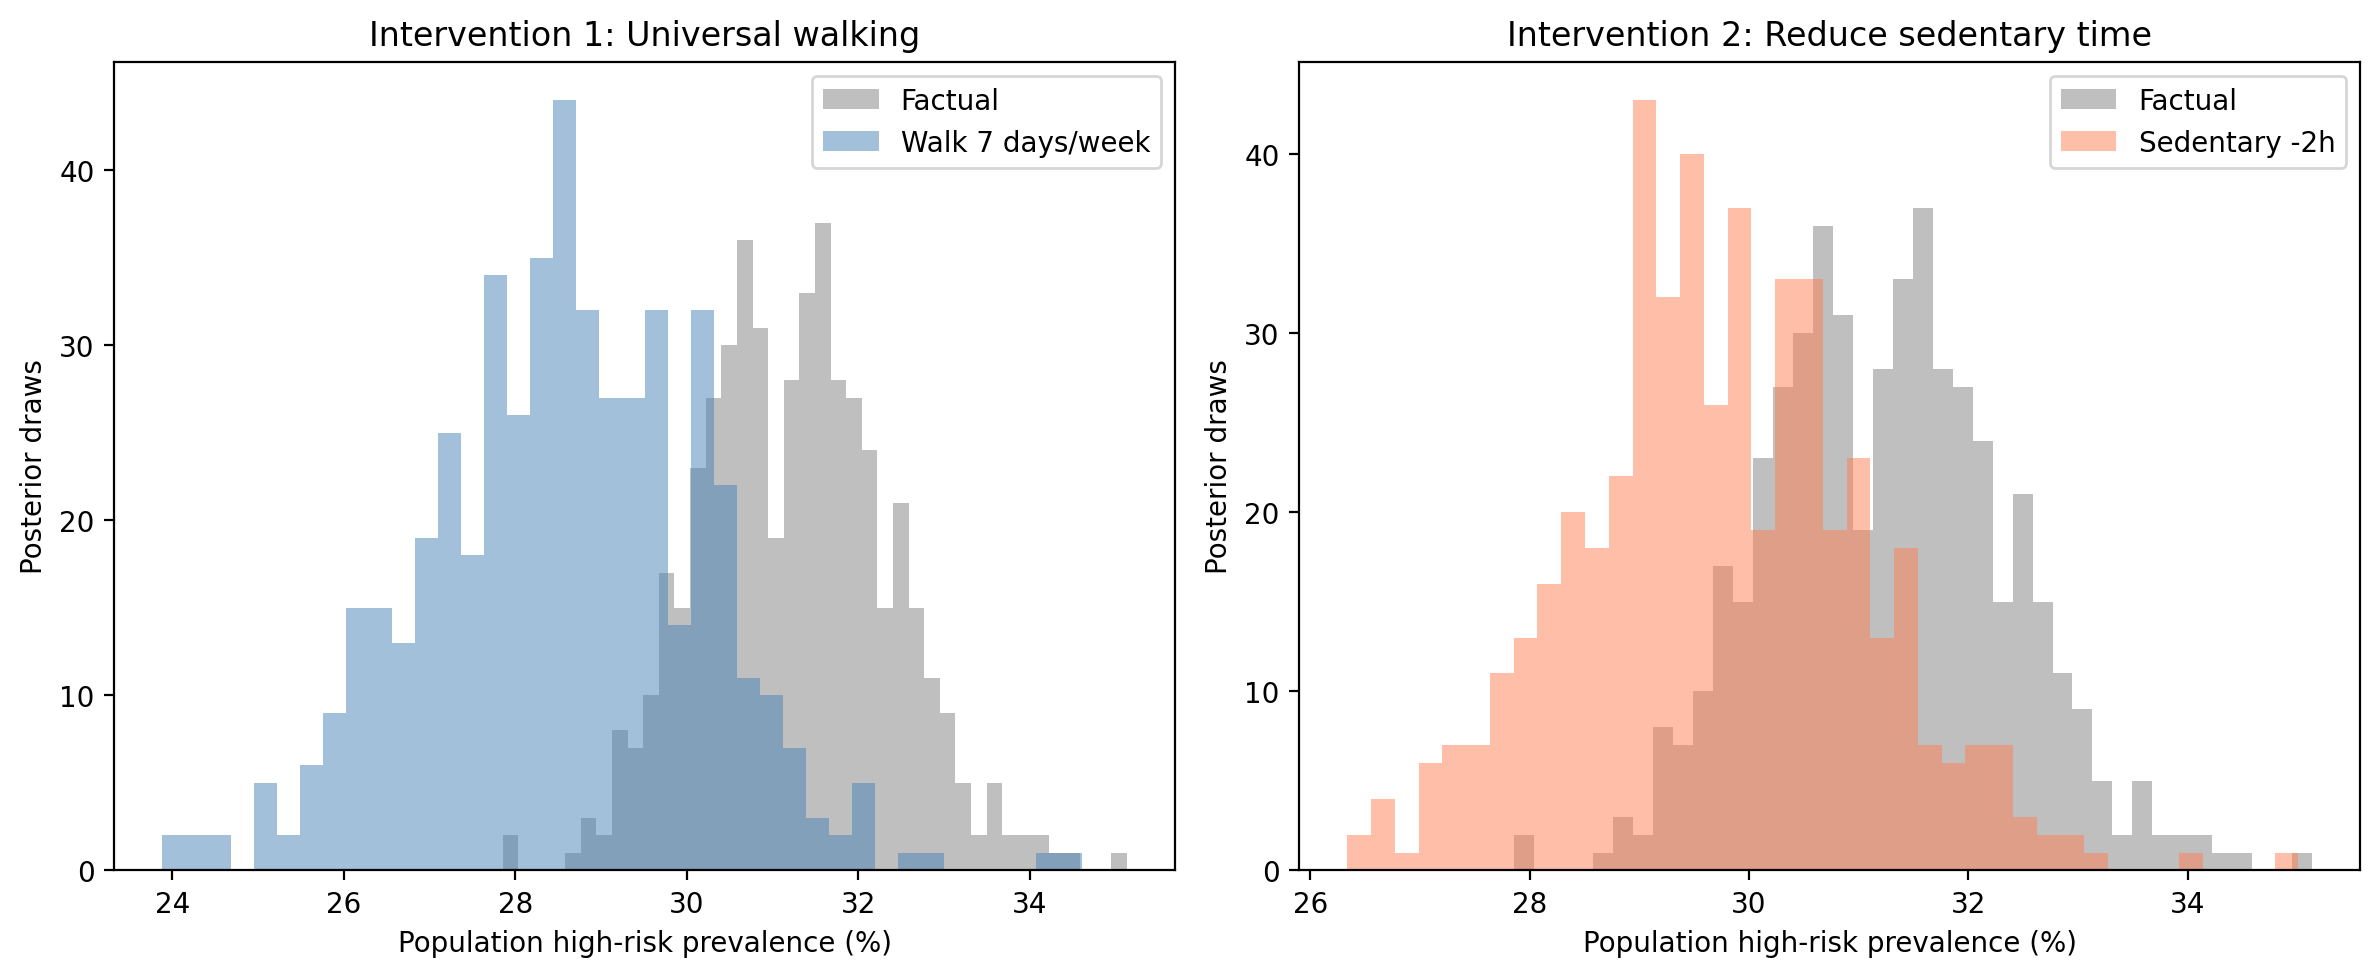

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(prev_factual * 100, bins=40, alpha=0.5, label='Factual', color='gray')
axes[0].hist(prev_walk7 * 100, bins=40, alpha=0.5, label='Walk 7 days/week', color='steelblue')
axes[0].set_xlabel('Population high-risk prevalence (%)')
axes[0].set_ylabel('Posterior draws')
axes[0].set_title('Intervention 1: Universal walking')
axes[0].legend()

axes[1].hist(prev_factual * 100, bins=40, alpha=0.5, label='Factual', color='gray')
axes[1].hist(prev_sed_minus2 * 100, bins=40, alpha=0.5, label='Sedentary -2h', color='coral')
axes[1].set_xlabel('Population high-risk prevalence (%)')
axes[1].set_ylabel('Posterior draws')
axes[1].set_title('Intervention 2: Reduce sedentary time')
axes[1].legend()

plt.tight_layout()
plt.show()

# counterfactual plots

In [31]:
cf_df = model_df.copy()
# intervention: walk at least 4 days a week, sit for no greater than 6 hours per day
cf_df["walk_days"] = np.maximum(cf_df["walk_days"], 4)
cf_df["sedentary_hours_raw"] = np.minimum(model_df["sedentary_hours"], 6)
cf_df["sedentary_hours_c"] = cf_df["sedentary_hours_raw"] - model_df["sedentary_hours"].mean()

# randomly select 1000 draws from the posterior, set seed for replicability
n_samples = 1000
np.random.seed(2)
sample_idx = np.random.choice(len(diabetes_posterior), size=n_samples, replace=False)
post_samples = diabetes_posterior.iloc[sample_idx]

# calculate counterfactual log-odds for every person, for every posterior draw (shape: 1501 people, 1000 posterior draws)
cf_logit_matrix = np.zeros((len(cf_df), n_samples))
for i, (_, row) in enumerate(post_samples.iterrows()):
    cf_logit = (
        row['beta_0']
        + row['beta_age'] * cf_df["age_c"]
        + row['beta_fem'] * cf_df["female"]
        + row['beta_sed'] * cf_df["sedentary_hours_c"] # intervened with cap
        + row['beta_vig'] * cf_df["vig_active"]
        + row['beta_walk'] * cf_df["walk_days"] # intervened with lower bound
        + row['beta_s1'] * sleep_dummies["sleep_<=5h"]
        + row['beta_s2'] * sleep_dummies["sleep_6h"]
        + row['beta_s3'] * sleep_dummies["sleep_8h"]
        + row['beta_s4'] * sleep_dummies["sleep_>=9h"]
    )
    cf_logit_matrix[:, i] = cf_logit

# convert log-odds to probabilities using the inverse logit (expit)
cf_prob_matrix = expit(cf_logit_matrix)

# calculate the population average risk for both scenarios
real_risk_mean = model_df["high_risk"].mean()
cf_pop_risk = cf_prob_matrix.mean(axis=0)



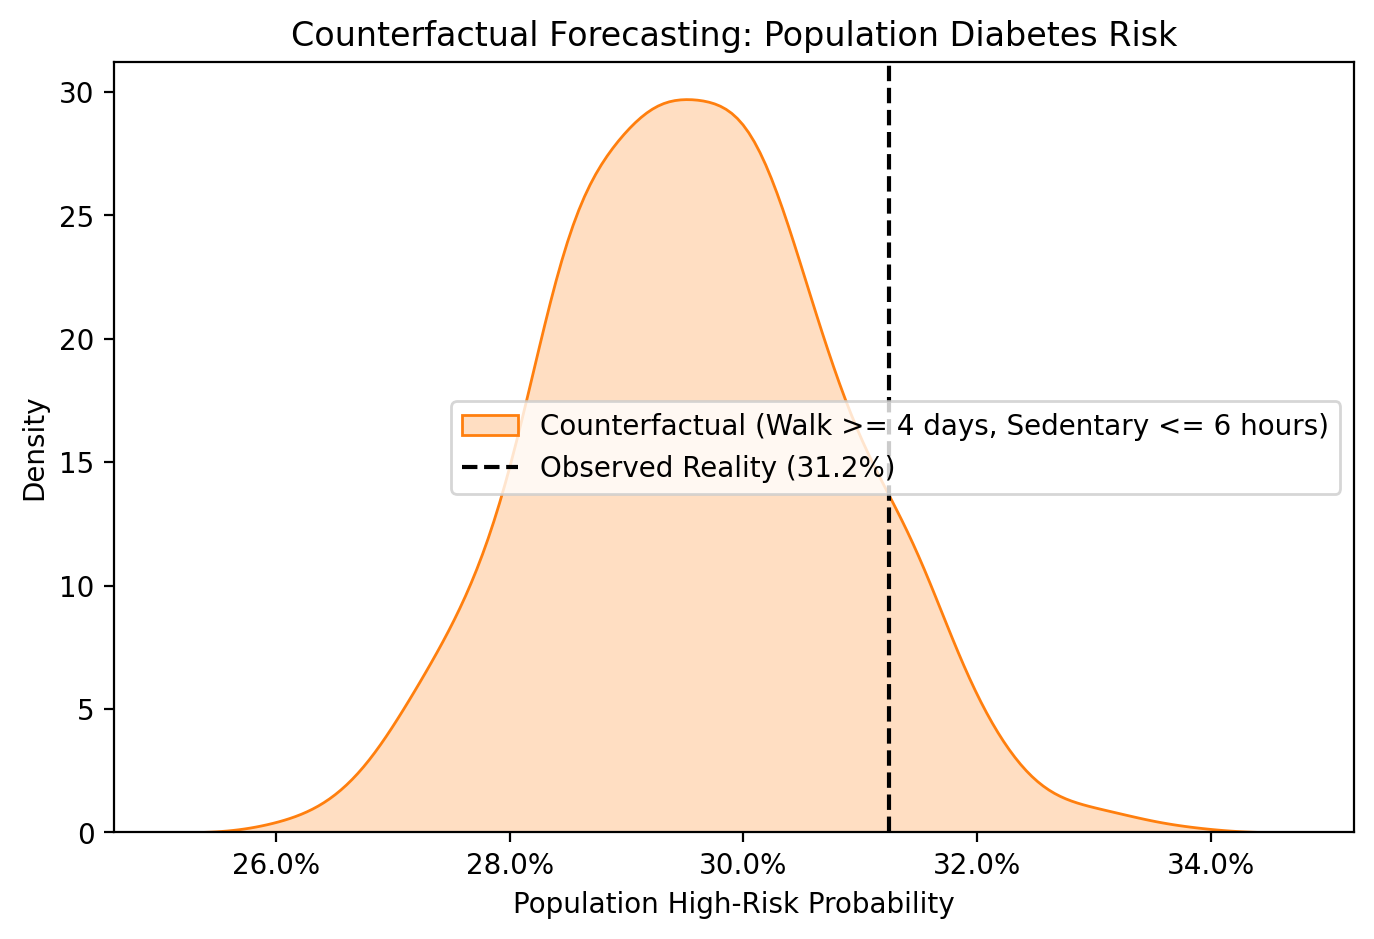

In [32]:
# plot the result
plt.figure(figsize=(8, 5))
sns.kdeplot(cf_pop_risk, fill=True, color="C1", label="Counterfactual (Walk >= 4 days, Sedentary <= 6 hours)")
plt.axvline(real_risk_mean, color="k", linestyle="--", label=f"Observed Reality ({real_risk_mean:.1%})")

plt.title("Counterfactual Forecasting: Population Diabetes Risk")
plt.xlabel("Population High-Risk Probability")
plt.ylabel("Density")
plt.legend()
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()